# Machine Learning Final - Employee Dataset

### Setup

In [74]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, r2_score
from sklearn.compose import ColumnTransformer
from timeit import default_timer as timer
from pycaret.classification import *
from torch import nn
import torch
from sklearn.neural_network import MLPClassifier

### Load Dataset

In [39]:
# Downloaded dataset as csv - read rows of csv file
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

## Part 1 -  Data Exploration

In [40]:
df.isnull().sum() # check for missing values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [41]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [42]:
df.shape # shows there are 1470 samples and 35 features 

(1470, 35)

In [43]:
df["Attrition"].value_counts() # shows imbalanced dataset

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [44]:
df.info() # show data type of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [45]:
df.describe() # distribution for numerical features

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [46]:
df.describe(include="object") # distribution for categorical features

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [47]:
df["EmployeeCount"].unique() # looking at unique values

array([1])

In [48]:
# Remove columns that have constant values or don't provide meaningful info to predict attrition
df = df.drop(columns=["EmployeeCount","EmployeeNumber","Over18","StandardHours"]) 

### Visuals

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

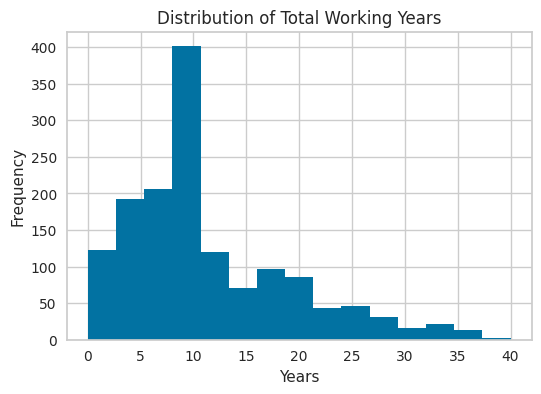

In [49]:
plt.figure(figsize=(6,4))
plt.hist(df["TotalWorkingYears"], bins=15)
plt.title("Distribution of Total Working Years")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.show() 
# indicates most employees have about 10 years of working experience

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

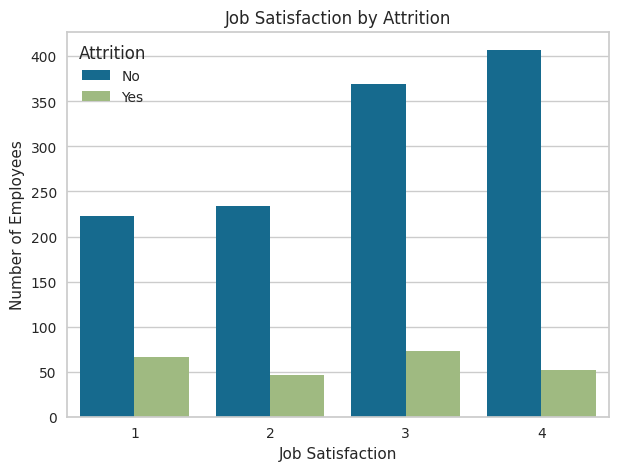

In [50]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")
plt.title("Job Satisfaction by Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.show() # there is no clear linear relationship between job satisfaction and attrition 

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

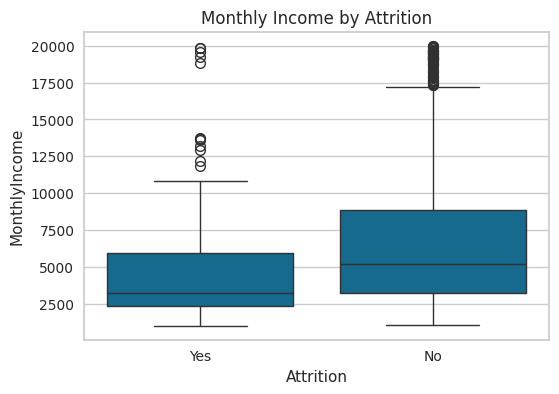

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income by Attrition")
plt.show()
# indicates median monthly income of employees who left the company were notably lower 
# than those who remained (however there are outliers for both those who stayed and left)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

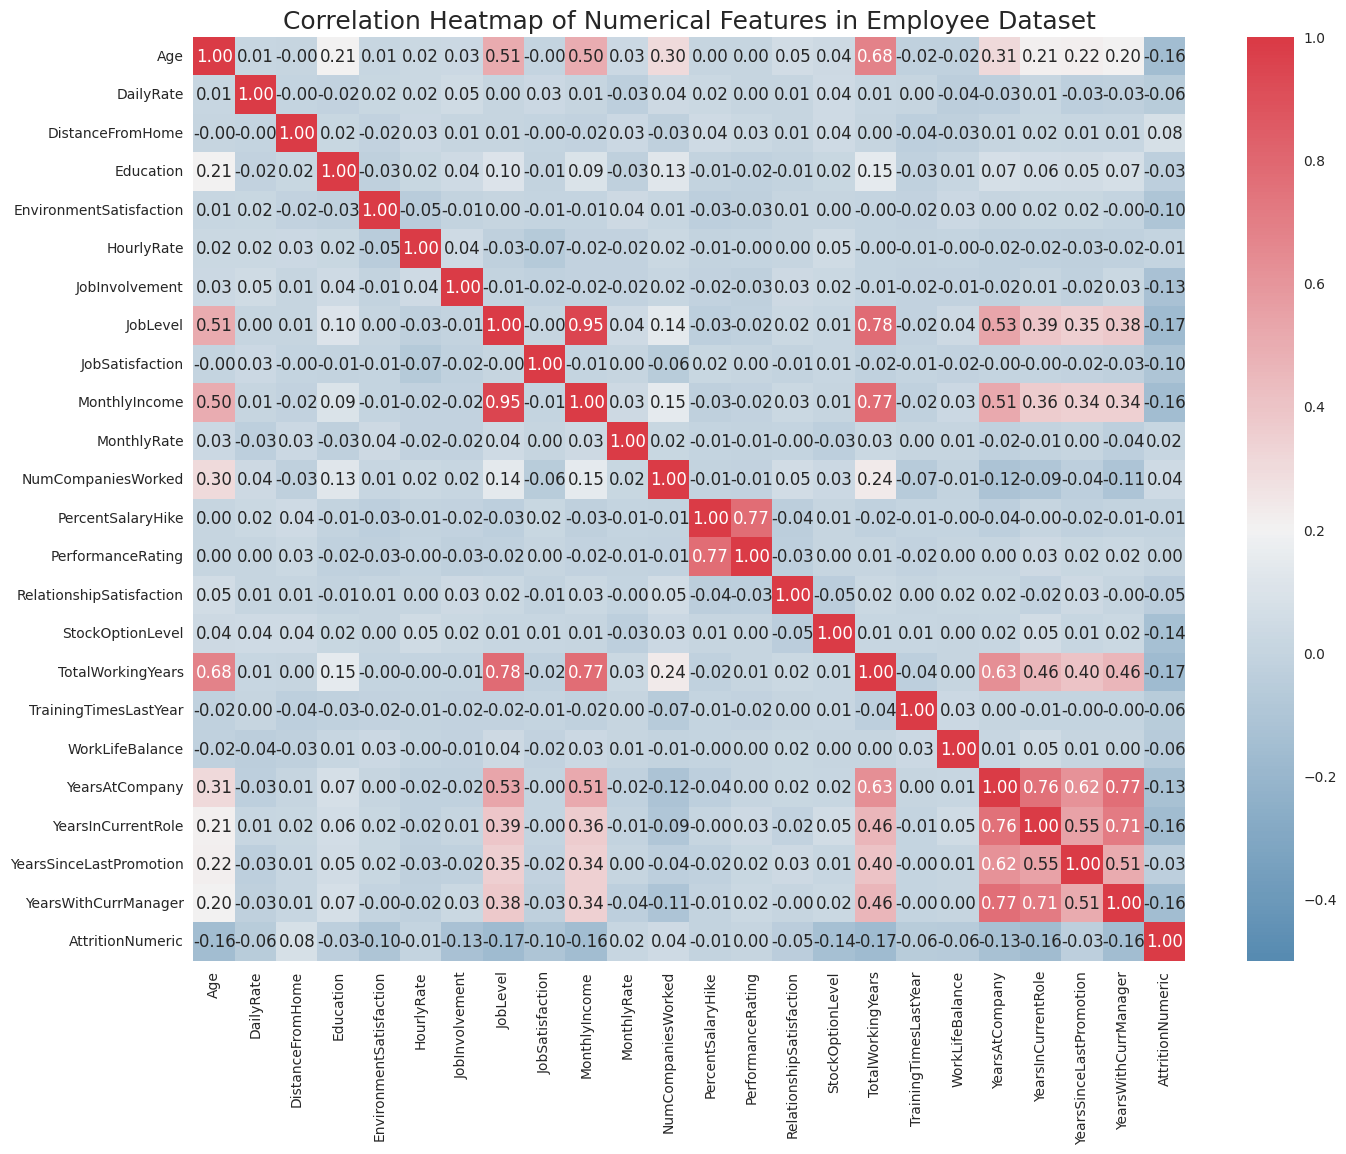

In [52]:
# Correlation heatmap
df["AttritionNumeric"] = df["Attrition"].map({"No": 0, "Yes": 1})  # add attrition numeric as column so atttrition will be included in heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
heatmap_employees = sns.heatmap(corr, fmt=".2f", annot=True, center=0.2, vmin=-0.5, vmax=1, cmap= sns.diverging_palette(240, 10, as_cmap=True))
heatmap_employees.set_xticklabels(corr.columns)
heatmap_employees.set_xticklabels(corr.columns)
plt.title("Correlation Heatmap of Numerical Features in Employee Dataset", fontsize=18)
plt.xticks()
plt.show()
# there are strong and moderate positive correlations between various numerical featres - some of which are intuitve - however there are no features with strong correlation to attrition, suggesting that there
# are multiple aspects that influence it rather than a dominant single feature

### Preparing Data for Processing

In [53]:

df = df.drop(columns=["AttritionNumeric"]) # remove to prevent data leakage - just wanted for heatmap
X = df.drop(columns=["Attrition"]) # exclude target and AttritionNumeric which was added for heatmap ( and removed "EmployeeCount","EmployeeNumber","Over18","StandardHours" before generating visuals)
y = df["Attrition"] # target

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # split data

In [55]:
# Columns for categorical and numerical data to apply preprocessing required for models
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns
numerical_columns = X_train.select_dtypes(include=["number"]).columns

In [56]:
# Preprocessing for categorical data
preprocessor_cat_cols = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), categorical_columns),
         ("num", "passthrough", numerical_columns)]) # need to include numbers otherwise ColumnTransformer will ignore
# Preprocessing for categorical and numerical data
preprocessor_cat_and_num_cols = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numerical_columns)])

## Part 2 -  Machine Learning

### Model 1 - Logistic Regression

In [57]:
# Helper function
def print_time(start, end, train=False):
    total_time= end-start
    train_or_test = "Train"
    if train == False:
        train_or_test = "Query"
    print(f"{train_or_test} time: {total_time:.3f} seconds")
    return total_time

def print_accuracy(acc_score, train=False):
    train_or_test = "Training"
    if train == False:
        train_or_test = "Testing"
    print(f"{train_or_test} accuracy: {acc_score:.3f}")
    return acc_score

In [58]:
logistic_model = LogisticRegression(random_state=42)
# Bundle preprocessing and model in a pipeline
pipeline_one = Pipeline(steps =[("preprocessor", preprocessor_cat_and_num_cols), ("model", logistic_model)])

model_1_start_time_train = timer()
# Preprocess training data and train model
pipeline_one.fit(X_train, y_train) 
model_1_end_time_train = timer()

train_preds_1 = pipeline_one.predict(X_train) # predict on training data

model_1_start_time_test = timer()
# Preprocess test data and predict target
preds_1 = pipeline_one.predict(X_test)
model_1_end_time_test = timer()

# Calculate and display accuracy
train_acc_1 = print_accuracy(accuracy_score(y_train, train_preds_1), True)
test_acc_1 = print_accuracy(accuracy_score(y_test, preds_1))

# Calculate and display time
total_train_time_model_1 = print_time(model_1_start_time_train, model_1_end_time_train, True)
total_test_time_model_1 = print_time(model_1_start_time_test, model_1_end_time_test)


Training accuracy: 0.902
Testing accuracy: 0.864
Train time: 0.026 seconds
Query time: 0.005 seconds


In [59]:
print(classification_report(y_test, preds_1))

              precision    recall  f1-score   support

          No       0.88      0.96      0.92       247
         Yes       0.64      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.76      0.65      0.68       294
weighted avg       0.85      0.86      0.85       294



### Model 2 - Decision Tree 

### Decision Tree with Default Parameters 

In [60]:
default_decision_tree = DecisionTreeClassifier(random_state=42)
# Bundle preprocessing and model in a pipeline
pipeline_two = Pipeline(steps =[("preprocessor", preprocessor_cat_cols), ("model", default_decision_tree)])

model_2_start_time_train = timer()
# Preprocess training data and train model
pipeline_two.fit(X_train, y_train) 
model_2_end_time_train = timer()

train_preds_2 = pipeline_two.predict(X_train) # predict on training data

model_2_start_time_test = timer()
# Preprocess test data and predict target
preds_2 = pipeline_two.predict(X_test)
model_2_end_time_test = timer()

# Calculate and display accuracy
train_acc_2 = print_accuracy(accuracy_score(y_train, train_preds_2), True)
test_acc_2 = print_accuracy(accuracy_score(y_test, preds_2))

# Calculate and display time
total_train_time_model_2 = print_time(model_2_start_time_train, model_2_end_time_train, True)
total_test_time_model_2 = print_time(model_2_start_time_test, model_2_end_time_test)
# training accuracy is perfect while testing accuracy is about 0.769 - indicates overfitting

Training accuracy: 1.000
Testing accuracy: 0.769
Train time: 0.024 seconds
Query time: 0.003 seconds


### Testing Values for Max_depth

In [61]:
train_accuracies = []
test_accuracies = []
for depth in range(1, 20):
    tree_model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    tree_pipeline = Pipeline(
        steps=[("preprocessor", preprocessor_cat_cols), ("model", tree_model)
        ])

    tree_pipeline.fit(X_train, y_train)

    train_preds_tree = tree_pipeline.predict(X_train) # predict on training data
    preds_tree = tree_pipeline.predict(X_test)
    train_acc_tree = print_accuracy(accuracy_score(y_train, train_preds_tree), True)
    test_acc_tree = print_accuracy(accuracy_score(y_test, preds_tree))
    train_accuracies.append(train_acc_tree)
    test_accuracies.append(test_acc_tree)

Training accuracy: 0.847
Testing accuracy: 0.799
Training accuracy: 0.854
Testing accuracy: 0.806


Training accuracy: 0.867
Testing accuracy: 0.837
Training accuracy: 0.878
Testing accuracy: 0.810
Training accuracy: 0.891
Testing accuracy: 0.833
Training accuracy: 0.908
Testing accuracy: 0.799
Training accuracy: 0.936
Testing accuracy: 0.830
Training accuracy: 0.953
Testing accuracy: 0.816
Training accuracy: 0.966
Testing accuracy: 0.806
Training accuracy: 0.980
Testing accuracy: 0.796
Training accuracy: 0.986
Testing accuracy: 0.789
Training accuracy: 0.989
Testing accuracy: 0.786
Training accuracy: 0.991
Testing accuracy: 0.789
Training accuracy: 0.994
Testing accuracy: 0.776
Training accuracy: 0.997
Testing accuracy: 0.803
Training accuracy: 0.999
Testing accuracy: 0.769
Training accuracy: 0.999
Testing accuracy: 0.765
Training accuracy: 1.000
Testing accuracy: 0.769
Training accuracy: 1.000
Testing accuracy: 0.769


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

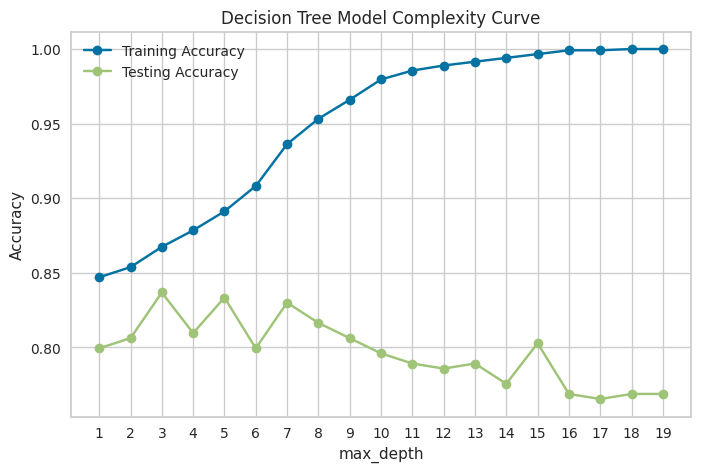

In [62]:
depths = range(1, 20)
plt.figure(figsize=(8, 5))
plt.plot(depths, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(depths,test_accuracies,marker="o", label="Testing Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Model Complexity Curve")
plt.xticks(depths)
plt.grid(True)
plt.legend() # show key for colours corresponding to training and testing accuracy
plt.show()
# max_depth of 3 has highest testing accuracy of approximately 84%

### Final Decision Tree

In [63]:
final_decision_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
# Bundle preprocessing and model in a pipeline
pipeline_two_final = Pipeline(steps =[("preprocessor", preprocessor_cat_cols), ("model", final_decision_tree)])

model_2_final_start_time_train = timer()
# Preprocess training data and train model
pipeline_two_final.fit(X_train, y_train) 
model_2_final_end_time_train = timer()

train_preds_2_final = pipeline_two_final.predict(X_train) # predict on training data

model_2_final_start_time_test = timer()
# Preprocess test data and predict target
preds_2_final = pipeline_two_final.predict(X_test)
model_2_final_end_time_test = timer()

# Calculate and display accuracy
train_acc_2_final = print_accuracy(accuracy_score(y_train, train_preds_2_final), True)
test_acc_2_final = print_accuracy(accuracy_score(y_test, preds_2_final))

# Calculate and display time
total_train_time_model_2_final = print_time(model_2_final_start_time_train, model_2_final_end_time_train, True)
total_test_time_model_2_final = print_time(model_2_final_start_time_test, model_2_final_end_time_test)

Training accuracy: 0.867
Testing accuracy: 0.837
Train time: 0.018 seconds
Query time: 0.006 seconds


### Model 3: AutoML & Hyperparameter Tuning

In [64]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [65]:
model_3_start_time_train = timer()
s = setup(data=df, target="Attrition", session_id=42)
best = compare_models( budget_time=1) # 1 minute
print(best)
model_3_end_time_train = timer()
# Calculate and display time
total_train_time_model_3 = print_time(model_3_start_time_train, model_3_end_time_train, True)
# Light Gradient Boosting Machine was selected as the best-performing model on the training data

,Description,Value
0,Session id,42
1,Target,Attrition
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(1470, 31)"
5,Transformed data shape,"(1470, 50)"
6,Transformed train set shape,"(1029, 50)"
7,Transformed test set shape,"(441, 50)"
8,Numeric features,23
9,Categorical features,7


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8804,0.8182,0.8804,0.8660,0.8577,0.4158,0.4561,0.5890
lda,Linear Discriminant Analysis,0.8785,0.8311,0.8785,0.8672,0.8656,0.4647,0.4856,0.1000
gbc,Gradient Boosting Classifier,0.8775,0.8059,0.8775,0.8651,0.8577,0.4211,0.4587,0.3810
ada,Ada Boost Classifier,0.8756,0.8178,0.8756,0.8640,0.8636,0.4607,0.4779,0.2390
ridge,Ridge Classifier,0.8708,0.8315,0.8708,0.8800,0.8345,0.3063,0.4075,0.1180
et,Extra Trees Classifier,0.8669,0.8052,0.8669,0.8590,0.8316,0.2958,0.3703,0.3550
rf,Random Forest Classifier,0.8610,0.8152,0.8610,0.8507,0.8176,0.2315,0.3171,0.3880
lr,Logistic Regression,0.8591,0.7808,0.8591,0.8387,0.8210,0.2500,0.3147,0.3160
dummy,Dummy Classifier,0.8387,0.5000,0.8387,0.7034,0.7651,0.0000,0.0000,0.0960
knn,K Neighbors Classifier,0.8183,0.5974,0.8183,0.7481,0.7734,0.0581,0.0651,0.1330


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)
Train time: 38.680 seconds


### Further Evaluation of Top AutoML Model

In [66]:
# PyCaret's internal training and testing targets from setup
y_train_pycaret = get_config("y_train")
y_test_pycaret = get_config("y_test")

train_preds_3 =  predict_model(best, data=get_config("X_train")) # predict on PyCaret's internal training data

model_3_start_time_test = timer()
# Preprocess PyCaret's internal test data and predict target 
preds_3 = predict_model(best, data=get_config("X_test")) 
model_3_end_time_test = timer()

# Extract predicted classes from generated dataframe
train_pred_labels_3 = train_preds_3["prediction_label"]
pred_labels_3 = preds_3["prediction_label"]

# Calculate and display accuracy
train_acc_3 = print_accuracy(accuracy_score(y_train_pycaret, train_pred_labels_3), True)
test_acc_3 = print_accuracy(accuracy_score(y_test_pycaret, pred_labels_3))

# Calculate and display time
total_train_time_model_3 = print_time(model_3_start_time_train, model_3_end_time_train, True)
total_test_time_model_3 = print_time(model_3_start_time_test, model_3_end_time_test)
# compare_models() evaluates models using cross-validation while accuracy below is using one fold, therefore discrepency is expected

Training accuracy: 1.000
Testing accuracy: 0.853
Train time: 38.680 seconds
Query time: 0.304 seconds


### Model 4: Random Forest

### Testing Values for Max_depth

In [67]:
train_accuracies = []
test_accuracies = []
for depth in range(1, 20):
    random_forest_model = RandomForestClassifier(max_depth=depth, random_state=42)

    forest_pipeline = Pipeline(
        steps=[("preprocessor", preprocessor_cat_cols), ("model", random_forest_model)
        ])

    forest_pipeline.fit(X_train, y_train)

    train_preds_forest = forest_pipeline.predict(X_train) # predict on training data
    preds_forest = forest_pipeline.predict(X_test)

    train_acc_forest = print_accuracy(accuracy_score(y_train, train_preds_forest), True)
    test_acc_forest = print_accuracy(accuracy_score(y_test, preds_forest))
    
    train_accuracies.append(train_acc_forest)
    test_accuracies.append(test_acc_forest)

Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.856
Testing accuracy: 0.840
Training accuracy: 0.871
Testing accuracy: 0.840
Training accuracy: 0.876
Testing accuracy: 0.830
Training accuracy: 0.885
Testing accuracy: 0.830
Training accuracy: 0.909
Testing accuracy: 0.837
Training accuracy: 0.927
Testing accuracy: 0.833
Training accuracy: 0.959
Testing accuracy: 0.827
Training accuracy: 0.980
Testing accuracy: 0.837
Training accuracy: 0.987
Testing accuracy: 0.833
Training accuracy: 0.998
Testing accuracy: 0.833
Training accuracy: 1.000
Testing accuracy: 0.837
Training accuracy: 1.000
Testing accuracy: 0.833
Training accuracy: 1.000
Testing accuracy: 0.837
Training accuracy: 1.000
Testing accuracy: 0.837
Training accuracy: 1.000
Testing accuracy: 0.837
Training accuracy: 1.000
Testing accuracy: 0.837
Training accuracy: 1.000
Testing accuracy: 0.837


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

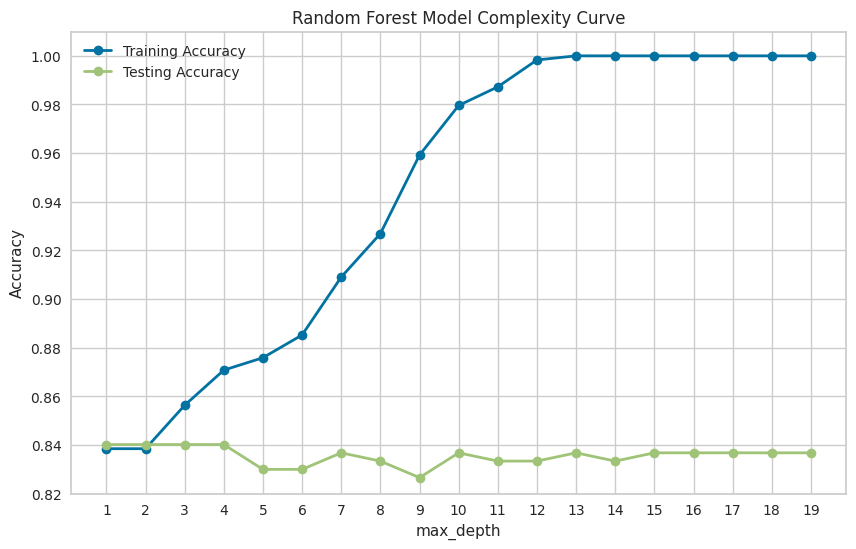

In [68]:
depths = range(1, 20)
plt.figure(figsize=(10, 6))
plt.ylim(0.82, 1.01)
plt.plot(depths, train_accuracies, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(depths,test_accuracies,marker="o",  linewidth=2, label="Testing Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Random Forest Model Complexity Curve")
plt.xticks(depths)
plt.yticks(np.arange(0.82, 1.01, 0.02))
plt.grid(True)
plt.legend() # show key for colours corresponding to training and testing accuracy
plt.show()
# max_depth of 1-4 have highest testing accuracy of 84% therefore max_depth =1 will be selected as it has a high testing accuracy and is less likely to severely overfit data

### Testing Values for N_estimators

In [69]:
train_accuracies = []
test_accuracies = []

for estimators in  range(10, 210, 10):
    random_forest_model_2 = RandomForestClassifier(max_depth=1, n_estimators= estimators, random_state=42)

    forest_pipeline_2 = Pipeline(
        steps=[("preprocessor", preprocessor_cat_cols), ("model", random_forest_model_2)
        ])

    forest_pipeline_2.fit(X_train, y_train)

    train_preds_forest_2 = forest_pipeline_2.predict(X_train) # predict on training data
    preds_forest_2 = forest_pipeline_2.predict(X_test)

    train_acc_forest_2 = print_accuracy(accuracy_score(y_train, train_preds_forest_2), True)
    test_acc_forest_2 = print_accuracy(accuracy_score(y_test, preds_forest_2))
    
    train_accuracies.append(train_acc_forest_2)
    test_accuracies.append(test_acc_forest_2)

Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840
Training accuracy: 0.838
Testing accuracy: 0.840


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

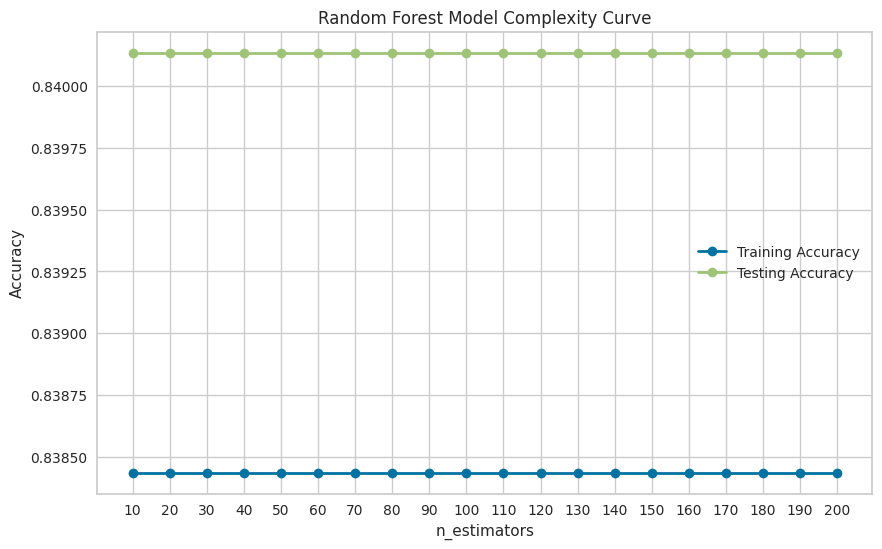

In [70]:
estimators = range(10, 210, 10)
plt.figure(figsize=(10, 6))
plt.plot(estimators, train_accuracies, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(estimators, test_accuracies,marker="o",  linewidth=2, label="Testing Accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest Model Complexity Curve")
plt.xticks(estimators)
plt.grid(True)
plt.legend() # show key for colours corresponding to training and testing accuracy
plt.show()
# since max_depth =1, changing the number of estimators does not make a signifcant difference and test accuracy remains constant value of 0.84 (and tain accuracy reamins = 0.838)

In [71]:
random_forest_model_with_hyperparams = RandomForestClassifier(random_state=42, max_depth=1, n_estimators=10)
# Bundle preprocessing and model in a pipeline
pipeline_four = Pipeline(steps =[("preprocessor", preprocessor_cat_cols), 
                                 ("model", random_forest_model_with_hyperparams)])

model_4_start_time_train = timer()
# Preprocess training data and train model
pipeline_four.fit(X_train, y_train) 
model_4_end_time_train = timer()

train_preds_4 = pipeline_four.predict(X_train) # predict on training data

model_4_start_time_test = timer()
# Preprocess test data and predict target
preds_4 = pipeline_four.predict(X_test)
model_4_end_time_test = timer()

# Calculate and display accuracy
train_acc_4 = print_accuracy(accuracy_score(y_train, train_preds_4), True)
test_acc_4 = print_accuracy(accuracy_score(y_test, preds_4))

# Calculate and display time
total_train_time_model_4 = print_time(model_4_start_time_train, model_4_end_time_train, True)
total_test_time_model_4 = print_time(model_4_start_time_test, model_4_end_time_test)

Training accuracy: 0.838
Testing accuracy: 0.840
Train time: 0.024 seconds
Query time: 0.003 seconds


### Model 5: Neural Network 

### Testing Layers

In [72]:

# Preserve employee names or row indices for displaying predictions
train_names = X_train.index.to_numpy()
test_names = X_test.index.to_numpy()

#  Convert to tensors
X_train_processed = preprocessor_cat_and_num_cols.fit_transform(X_train)
X_test_processed = preprocessor_cat_and_num_cols.transform(X_test)

# Convert target labels: No = 0, Yes = 1
y_train_numeric = y_train.map({"No": 0, "Yes": 1})
y_test_numeric = y_test.map({"No": 0, "Yes": 1})


X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
# CrossEntropyLoss requires one-dimensional integer targets
y_train_tensor = torch.tensor(y_train_numeric.to_numpy(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test_numeric.to_numpy(), dtype=torch.long)


In [79]:
class AttritionClassifier(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.linear_layer_1 = nn.Linear(in_features=in_features, out_features=15)
        self.relu_layer_2 = nn.ReLU()
        self.linear_layer_3 = nn.Linear(in_features=15, out_features=25)
        self.relu_layer_4 = nn.ReLU()
        self.linear_layer_5 = nn.Linear(in_features=25, out_features=2)

    def forward(self, x):
        x = self.linear_layer_1(x)
        x = self.relu_layer_2(x)
        x = self.linear_layer_3(x)
        x = self.relu_layer_4(x)
        x = self.linear_layer_5(x)
        return x

# ReLU allows the model to learn complex relationships that are non-linear. Without it, various linear layers
# would be equivalent to using single linear layer 
    

In [80]:
# Helper function
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return correct / len(y_true)

In [84]:

torch.manual_seed(42)
model = AttritionClassifier(in_features=X_train_tensor.shape[1])

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# track diff values
epoch_count = []
loss_values = []
test_loss_values = []
epochs = 50

model_5_start_time_train = timer()

for epoch in range(epochs):
    # Train step -> logits, loss, zero_grad, backward, step
    model.train() # set model to training mode
   
    optimizer.zero_grad() # reset for every pass in loop
    train_logits = model(X_train_tensor) # forward pass
    loss = loss_fn(train_logits, y_train_tensor) # calculate cost/loss
    loss.backward() # perform backpropogation - calculate gradient of every parameter
    optimizer.step() # update model parameters
    model_5_end_time_train = timer()
    total_train_time_model_5 = print_time(model_5_start_time_train, model_5_end_time_train,True)
    epoch_count.append(epoch)
    loss_values.append(loss.item())
    model_5_start_time_test = timer()
    model.eval() # turns off diff settings for model that are not needed for testing

    with torch.inference_mode():  # turns off gradient tracking + other things
        test_logits = model(X_test_tensor)
        test_loss = loss_fn(test_logits, y_test_tensor) 
        test_preds = torch.argmax(test_logits, dim=1)
        test_accuracy = accuracy_fn(y_true=y_test_tensor, y_pred=test_preds)
    test_loss_values.append(test_loss.item())
    model_5_end_time_test= timer()

    total_test_time_model_5 = print_time(model_5_start_time_test, model_5_end_time_test)
    # Every 50 epochs, evaluate on test set and print loss + accuracy
    if epoch % 10 == 0 or epoch == epochs - 1: # so prints last epoch as well
        print(f"Epoch: {epoch} | Loss: {loss} | Test accuracy: {test_accuracy}" )





Train time: 0.002 seconds
Query time: 0.000 seconds
Epoch: 0 | Loss: 0.7790096998214722 | Test accuracy: 0.336734693877551
Train time: 0.005 seconds
Query time: 0.000 seconds
Train time: 0.007 seconds
Query time: 0.000 seconds
Train time: 0.008 seconds
Query time: 0.000 seconds
Train time: 0.010 seconds
Query time: 0.000 seconds
Train time: 0.012 seconds
Query time: 0.000 seconds
Train time: 0.014 seconds
Query time: 0.000 seconds
Train time: 0.015 seconds
Query time: 0.000 seconds
Train time: 0.016 seconds
Query time: 0.000 seconds
Train time: 0.018 seconds
Query time: 0.000 seconds
Train time: 0.019 seconds
Query time: 0.000 seconds
Epoch: 10 | Loss: 0.43191221356391907 | Test accuracy: 0.8401360544217688
Train time: 0.020 seconds
Query time: 0.000 seconds
Train time: 0.021 seconds
Query time: 0.000 seconds
Train time: 0.022 seconds
Query time: 0.000 seconds
Train time: 0.024 seconds
Query time: 0.000 seconds
Train time: 0.025 seconds
Query time: 0.000 seconds
Train time: 0.026 secon

In [85]:
print(f"Training accuracy: {test_accuracy:.3f}")
print(f"Testing accuracy: {test_accuracy:.3f}")

print(f"Training time: {total_train_time_model_5:.3f} seconds")
print(f"Testing time: {total_test_time_model_5:.3f} seconds")

Training accuracy: 0.850
Testing accuracy: 0.850
Training time: 0.067 seconds
Testing time: 0.000 seconds


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

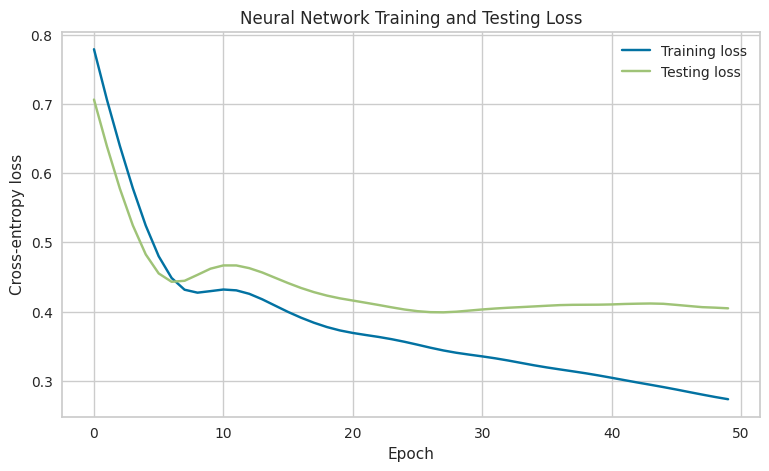

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(epoch_count, loss_values, label="Training loss")
plt.plot(epoch_count, test_loss_values, label="Testing loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Neural Network Training and Testing Loss")
plt.legend()
plt.grid(True)
plt.show()